<a href="https://colab.research.google.com/github/MO7AMEDNABIL/AI-Powered-Assistant-for-Churn-Prediction/blob/main/ML_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Read data

In [2]:
customer_churn_df= pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
customer_churn_df.head()

,customerID,gender,Senior_Citizen,Is_Married,Dependents,tenure,Phone_Service,Dual,Internet_Service,Online_Security,...,Device_Protection,Tech_Support,Streaming_TV,Streaming_Movies,Contract,Paperless_Billing,Payment_Method,Monthly_Charges,Total_Charges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
customer_churn_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customerID         7043 non-null   object 
 1   gender             7043 non-null   object 
 2   Senior_Citizen     7043 non-null   int64  
 3   Is_Married         7043 non-null   object 
 4   Dependents         7043 non-null   object 
 5   tenure             7043 non-null   int64  
 6   Phone_Service      7043 non-null   object 
 7   Dual               7043 non-null   object 
 8   Internet_Service   7043 non-null   object 
 9   Online_Security    7043 non-null   object 
 10  Online_Backup      7043 non-null   object 
 11  Device_Protection  7043 non-null   object 
 12  Tech_Support       7043 non-null   object 
 13  Streaming_TV       7043 non-null   object 
 14  Streaming_Movies   7043 non-null   object 
 15  Contract           7043 non-null   object 
 16  Paperless_Billing  7043 

In [4]:
customer_churn_df.isnull().sum()

,0
customerID,0
gender,0
Senior_Citizen,0
Is_Married,0
Dependents,0
tenure,0
Phone_Service,0
Dual,0
Internet_Service,0
Online_Security,0


In [ ]:
customer_churn_df.describe()

,Senior_Citizen,tenure,Monthly_Charges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


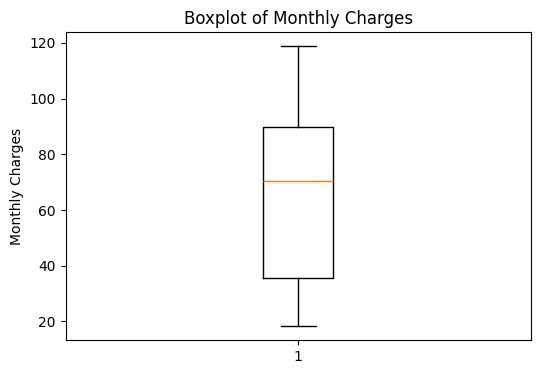

In [6]:

plt.figure(figsize=(6, 4))
plt.boxplot(customer_churn_df['Monthly_Charges'].dropna())
plt.title('Boxplot of Monthly Charges')
plt.ylabel('Monthly Charges')
plt.show()

# There is class imbalance


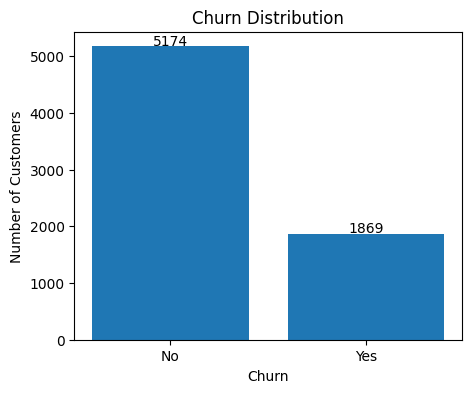

In [8]:
import matplotlib.pyplot as plt

# Count values
churn_counts = customer_churn_df['Churn'].value_counts().sort_index()

# Plot
plt.figure(figsize=(5, 4))
plt.bar(['No', 'Yes'], churn_counts.values)

plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')

# Show count on top of each bar
for i, count in enumerate(churn_counts.values):
    plt.text(i, count + 20, str(count), ha='center')

plt.show()

# preprocessing data


In [9]:
customer_churn_df['Churn'] = customer_churn_df['Churn'].map({'Yes': 1, 'No': 0})

In [10]:
yes_no_columns = ['Is_Married', 'Dependents',"Paperless_Billing",'Phone_Service']

for col in yes_no_columns:
    customer_churn_df[col] = customer_churn_df[col].map({'Yes': 1, 'No': 0})

In [11]:
import pandas as pd

columns = [
    'Online_Security',
    'Online_Backup',
    'Device_Protection',
    'Tech_Support',
    'Streaming_TV',
    'Streaming_Movies',
    'Dual',
    'Internet_Service',
    'Payment_Method'
]

customer_churn_df = pd.get_dummies(customer_churn_df, columns=columns, dtype=int)
customer_churn_df.head()

,customerID,gender,Senior_Citizen,Is_Married,Dependents,tenure,Phone_Service,Contract,Paperless_Billing,Monthly_Charges,...,Dual_No,Dual_No phone service,Dual_Yes,Internet_Service_DSL,Internet_Service_Fiber optic,Internet_Service_No,Payment_Method_Bank transfer (automatic),Payment_Method_Credit card (automatic),Payment_Method_Electronic check,Payment_Method_Mailed check
0,7590-VHVEG,Female,0,1,0,1,0,Month-to-month,1,29.85,...,0,1,0,1,0,0,0,0,1,0
1,5575-GNVDE,Male,0,0,0,34,1,One year,0,56.95,...,1,0,0,1,0,0,0,0,0,1
2,3668-QPYBK,Male,0,0,0,2,1,Month-to-month,1,53.85,...,1,0,0,1,0,0,0,0,0,1
3,7795-CFOCW,Male,0,0,0,45,0,One year,0,42.30,...,0,1,0,1,0,0,1,0,0,0
4,9237-HQITU,Female,0,0,0,2,1,Month-to-month,1,70.70,...,1,0,0,0,1,0,0,0,1,0


In [12]:
customer_churn_df['Total_Charges'] = pd.to_numeric(
    customer_churn_df['Total_Charges'],
    errors='coerce'
)

customer_churn_df.dropna(subset=['Total_Charges'], inplace=True)

In [13]:
contract_map = {
    'Month-to-month': 0,
    'One year': 1,
    'Two year': 2
}

customer_churn_df['Contract'] = customer_churn_df['Contract'].map(contract_map)

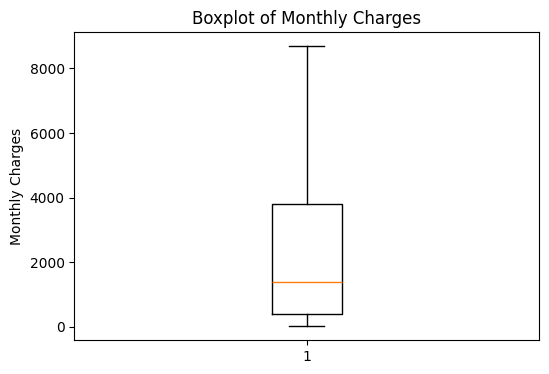

In [15]:
plt.figure(figsize=(6, 4))
plt.boxplot(customer_churn_df['Total_Charges'].dropna())
plt.title('Boxplot of Monthly Charges')
plt.ylabel('Monthly Charges')
plt.show()

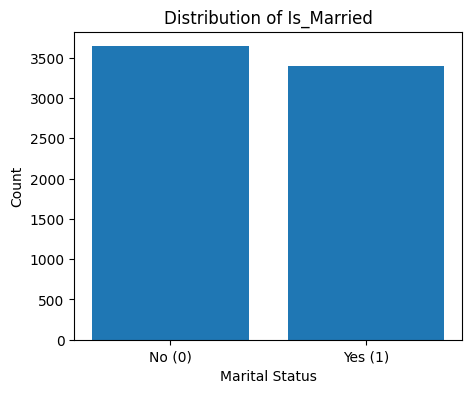

In [17]:
married_counts = customer_churn_df['Is_Married'].value_counts().sort_index()

plt.figure(figsize=(5, 4))
plt.bar(['No (0)', 'Yes (1)'], married_counts.values)
plt.title('Distribution of Is_Married')
plt.ylabel('Count')
plt.xlabel('Marital Status')
plt.show()

In [14]:
customer_churn_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 40 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   customerID                                7032 non-null   object 
 1   gender                                    7032 non-null   object 
 2   Senior_Citizen                            7032 non-null   int64  
 3   Is_Married                                7032 non-null   int64  
 4   Dependents                                7032 non-null   int64  
 5   tenure                                    7032 non-null   int64  
 6   Phone_Service                             7032 non-null   int64  
 7   Contract                                  7032 non-null   int64  
 8   Paperless_Billing                         7032 non-null   int64  
 9   Monthly_Charges                           7032 non-null   float64
 10  Total_Charges                            

# split data and drop unimportant columns after trials

In [ ]:
X = customer_churn_df.drop(columns=["customerID", "Churn" ,'gender','Online_Security_No',
    'Online_Backup_No',
    'Device_Protection_No',
    'Tech_Support_No',
    'Streaming_TV_No',
    'Streaming_Movies_No',
    'Dual_No',
    'Internet_Service_No',
    'Payment_Method_Mailed check'])
y = customer_churn_df["Churn"]

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 5.5 MB/s eta 0:00:00


# Train model by get the best hyperprameters and accuracy

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve, f1_score
)
from sklearn.feature_selection import SelectFromModel
import optuna

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Class imbalance
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
base_spw = neg / pos
print(f"scale_pos_weight baseline: {base_spw:.2f}  (neg={neg}, pos={pos})\n")

def objective(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 600),
        'max_depth'        : trial.suggest_int('max_depth', 3, 8),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'min_child_weight' : trial.suggest_int('min_child_weight', 1, 10),
        'subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma'            : trial.suggest_float('gamma', 0, 5),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 0, 2),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 0, 2),
        'scale_pos_weight' : trial.suggest_float('scale_pos_weight', 1.5, 4.0),
        'eval_metric'      : 'auc',
        'random_state'     : 42,
    }
    model = XGBClassifier(**params)
    cv    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    score = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc')
    return score.mean()

print("Running Optuna hyperparameter search (100 trials) ...")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100, show_progress_bar=True)

print(f"\nBest CV AUC  : {study.best_value:.4f}")
print(f"Best Params  : {study.best_params}\n")



best_params = study.best_params.copy()
best_params.update({'eval_metric': 'auc', 'random_state': 42})

xgb_final = XGBClassifier(**best_params, early_stopping_rounds=20)
xgb_final.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=25
)

y_prob = xgb_final.predict_proba(X_test)[:, 1]
print(f"\nTest ROC-AUC (default threshold): {roc_auc_score(y_test, y_prob):.4f}\n")

[I 2026-06-24 17:03:42,038] A new study created in memory with name: no-name-39ac5ffe-79e7-446b-af39-e7f7bcfc042a


scale_pos_weight baseline: 2.76  (neg=4130, pos=1495)

Running Optuna hyperparameter search (100 trials) ...


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-06-24 17:03:50,348] Trial 0 finished with value: 0.8391316494853708 and parameters: {'n_estimators': 584, 'max_depth': 5, 'learning_rate': 0.034336405751931476, 'min_child_weight': 3, 'subsample': 0.809130425818271, 'colsample_bytree': 0.8471824885591626, 'gamma': 0.15225185797662688, 'reg_alpha': 0.09406355757032037, 'reg_lambda': 0.9444612789154838, 'scale_pos_weight': 2.6445133731762325}. Best is trial 0 with value: 0.8391316494853708.
[I 2026-06-24 17:03:52,074] Trial 1 finished with value: 0.8468458218273989 and parameters: {'n_estimators': 513, 'max_depth': 5, 'learning_rate': 0.05012926459833491, 'min_child_weight': 7, 'subsample': 0.8549651277086827, 'colsample_bytree': 0.6094801532248108, 'gamma': 1.9527529986758574, 'reg_alpha': 1.93714993628147, 'reg_lambda': 1.9728936336914953, 'scale_pos_weight': 2.945967482323013}. Best is trial 1 with value: 0.8468458218273989.
[I 2026-06-24 17:03:55,987] Trial 2 finished with value: 0.838333589770583 and parameters: {'n_estimato

In [ ]:
y_pred = (y_prob >= 0.35).astype(int)

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[707 326]
 [ 61 313]]


In [ ]:
from sklearn.metrics import accuracy_score

y_pred = xgb_final.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.7811


In [ ]:
pip install shap

# SHAP used to determine which features contributed most to the prediction

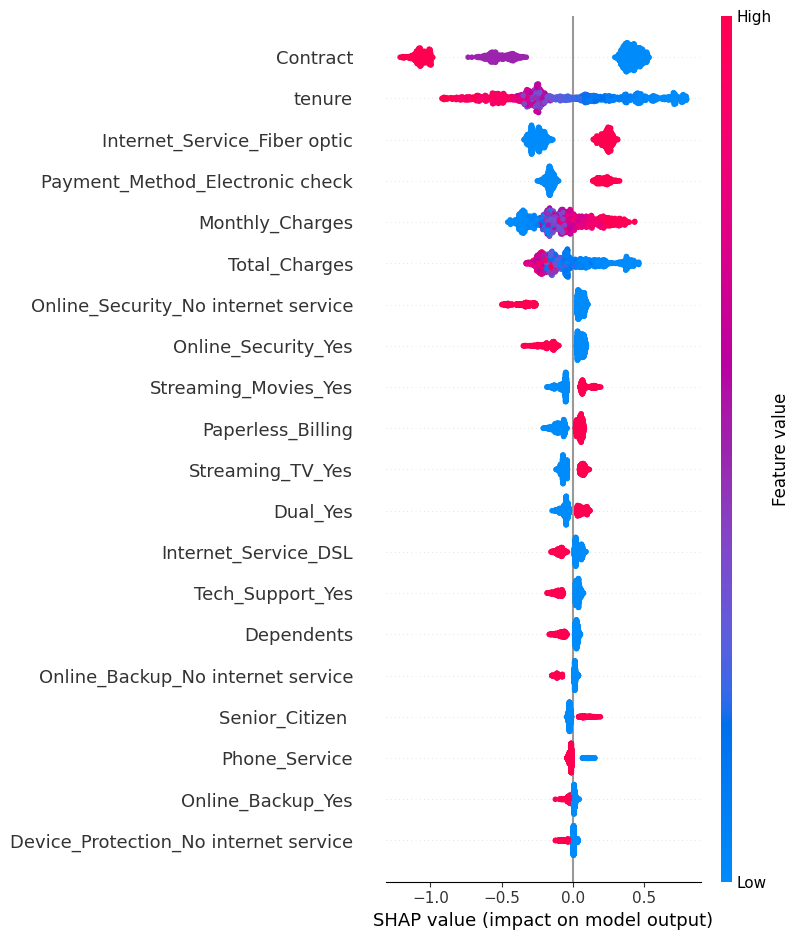

In [ ]:
import shap

explainer = shap.TreeExplainer(xgb_final)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

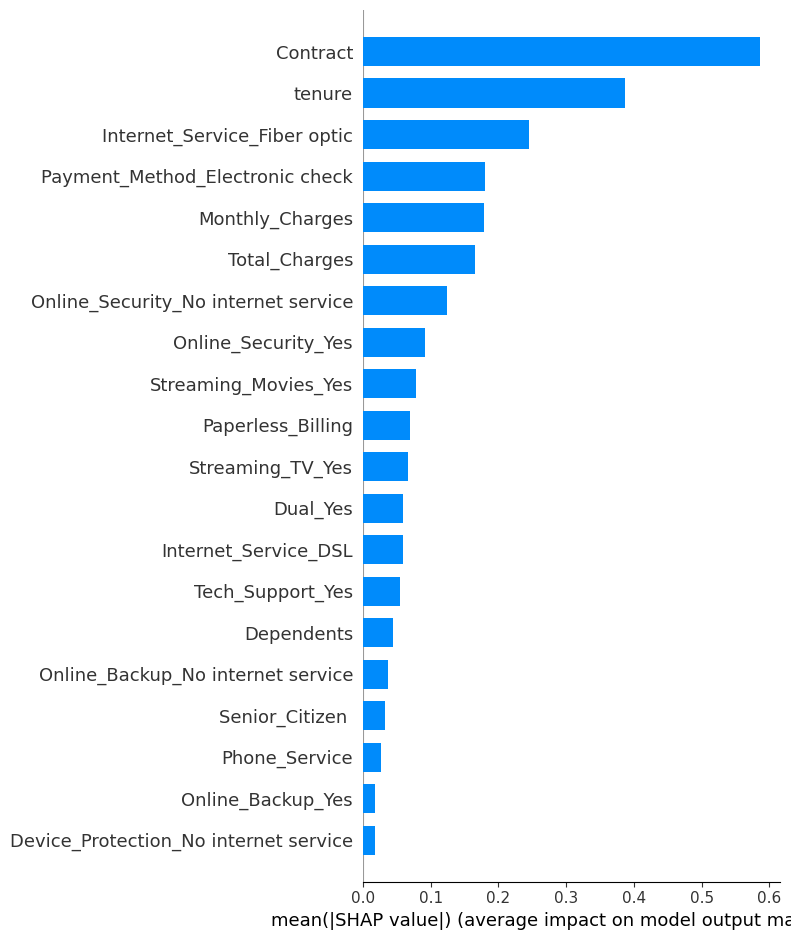

In [ ]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

# Save model for next step

In [ ]:
import joblib

joblib.dump(xgb_final, "xgb_churn_model.pkl")

['xgb_churn_model.pkl']

In [ ]:
joblib.dump(best_params, "best_params.pkl")

['best_params.pkl']

In [ ]:
import joblib

feature_columns = X.columns.tolist()

joblib.dump(feature_columns, "feature_columns.pkl")

['feature_columns.pkl']